# Source: [Microsoft Learn](https://learn.microsoft.com/)

# Safari Challenge

In this challenge, you must use what you've learned to train a convolutional neural network model that classifies images of animals you might find on a safari adventure.

## Explore the data

The training images you must use are in the **/safari/training** folder. Run the cell below to see an example of each image class, and note the shape of the images (which indicates the dimensions of the image and its color channels).

4 classes:
['elephant', 'giraffe', 'lion', 'zebra']


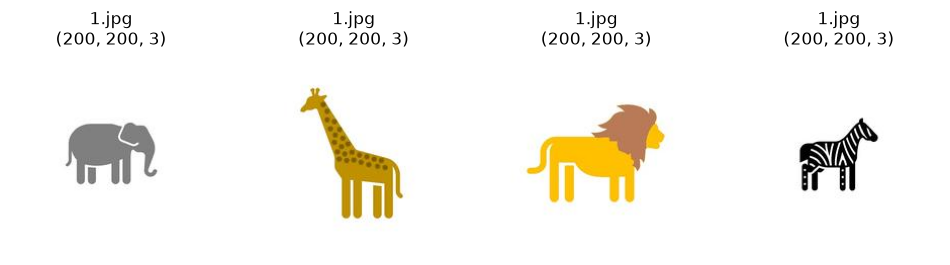

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_path = 'data/safari/training'

# I am here getting only valid class names (ignoring hidden files/folders)
classes = [c for c in os.listdir(data_path) if not c.startswith('.')]
classes.sort()
print(len(classes), 'classes:')
print(classes)

fig = plt.figure(figsize=(12, 12))
i = 0

for sub_dir in classes:
    i += 1
    sub_dir_path = os.path.join(data_path, sub_dir)
    
    # filtering out hidden system folders/files
    all_files = os.listdir(sub_dir_path)
    valid_images = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not valid_images:
        print(f"Warning: No valid images found in folder: {sub_dir}")
        continue
        
    img_file = valid_images[0]
    img_path = os.path.join(sub_dir_path, img_file)
    
    img = mpimg.imread(img_path)
    img_shape = img.shape
    
    a = fig.add_subplot(1, len(classes), i)
    a.axis('off')
    plt.imshow(img)
    a.set_title(f"{img_file}\n{img_shape}")

plt.show()


Now that you've seen the images, use your preferred framework (PyTorch or TensorFlow) to train a CNN classifier for them. Your goal is to train a classifier with a validation accuracy of 95% or higher.

Add cells as needed to create your solution.

> **Note**: There is no single "correct" solution.

# Preparing our data

In [2]:
import tensorflow as tf

img_size = (128, 128)
batch_size = 30
data_path = 'data/safari/training' 

print("Getting Data...")

print("Preparing training dataset...")
# Modern replacement for flow_from_directory
train_generator = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.3,
    subset="training",
    seed=123,  # Seed ensures train/val splits do not overlap
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'  # Replaces class_mode='categorical'
)

print("Preparing validation dataset...")
validation_generator = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# class names
classnames = train_generator.class_names

# normalize pixel values
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_generator = train_generator.map(lambda x, y: (normalization_layer(x), y))
validation_generator = validation_generator.map(lambda x, y: (normalization_layer(x), y))

print('Data generators ready')


Getting Data...
Preparing training dataset...
Found 397 files belonging to 4 classes.
Using 278 files for training.
Preparing validation dataset...
Found 397 files belonging to 4 classes.
Using 119 files for validation.
Data generators ready


# Creating our CNN Model
now we have to define the layers of CNN and compiling them for multiclass classification.

In [3]:
# Defining a CNN classifier network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# our model
model = Sequential([
    Input(shape=img_size + (3,)),  # (128, 128, 3)

    Conv2D(32, (6, 6), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(32, (6, 6), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(32, (6, 6), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Dropout(0.2),

    Flatten(),

    # output layer (4 classes: elephant, giraffe, lion, zebra)
    Dense(len(classnames), activation='softmax')
])

# compilation
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 123, 123, 32)        │           3,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 61, 61, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 56, 56, 32)          │          36,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 23, 23, 32)          │          36,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 11, 11, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 11, 11, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3872)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │          15,492 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 92,772 (362.39 KB)

 Trainable params: 92,772 (362.39 KB)

 Non-trainable params: 0 (0.00 B)

# Training our Model
with the layers of the CNN defined, we are ready to train the model using our image data. In the example below, we use 5 iterations (epochs) to train the model.

In [4]:
# Train the model
num_epochs = 5

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=num_epochs
)

Epoch 1/5


C:\Users\USER\Desktop\ATS-Training\Week-01\Deep Learning with Python\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.4317 - loss: 1.1749 - val_accuracy: 0.6555 - val_loss: 0.6434
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 314ms/step - accuracy: 0.9245 - loss: 0.2355 - val_accuracy: 1.0000 - val_loss: 0.0276
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step - accuracy: 0.9964 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 308ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 1.2087e-04
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 314ms/step - accuracy: 1.0000 - loss: 5.0445e-04 - val_accuracy: 1.0000 - val_loss: 2.1836e-04


# **Final Results:**
- Training Accuracy: **100%**
- Validation Accuracy: **100%**

The validation accuracy exceeds the required **95%**, so the Safari Challenge has been successfully completed.

## tracking average training and validation loss history

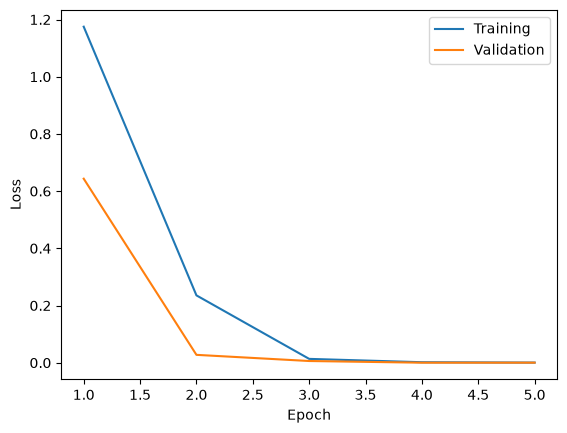

In [5]:
from matplotlib import pyplot as plt

epoch_nums = range(1, num_epochs + 1)
training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

plt.plot(epoch_nums, training_loss)
plt.plot(epoch_nums, validation_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

## Save your model

Add code below to save your model's trained weights.

In [6]:
# Code to save your model
modelFileName = 'models/safari_classifier.keras'
model.save(modelFileName)

del model 
print('Model saved as', modelFileName)

Model saved as models/safari_classifier.keras


## Use the trained model

Now that we've trained your model, modify the following code as necessary to use it to predict the classes of the provided test images.

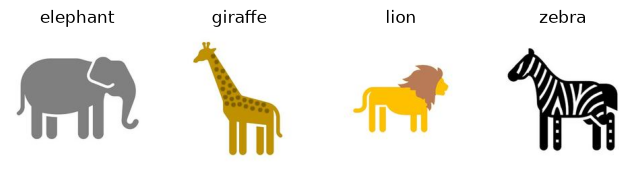

In [10]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# function to predict the class of an image
def predict_image(classifier, image):
    # The model expects a batch of images as input, so we'll create an array of 1 image
    image = tf.image.resize(image, img_size)
    imgfeatures = img_to_array(image)
    imgfeatures = imgfeatures.reshape(1, imgfeatures.shape[0], imgfeatures.shape[1], imgfeatures.shape[2])

    # we need to format the input to match the training data
    # The generator loaded the values as floating point numbers
    # and normalized the pixel values
    imgfeatures = imgfeatures.astype('float32')
    imgfeatures /= 255

    # Default value
    index = 0

    # !!Add your code here to predict an image class from your model!!
    predictions = classifier.predict(imgfeatures, verbose=0)
    index = np.argmax(predictions)

    # Return the predicted index
    return index


# Load your model
model = load_model("models/safari_classifier.keras")

test_data_path = 'data/safari/test'

# Show the test images with predictions
fig = plt.figure(figsize=(8, 12))
i = 0

for img_file in os.listdir(test_data_path):
    if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
        i += 1
        img_path = os.path.join(test_data_path, img_file)
        img = mpimg.imread(img_path)

        # Get the image class prediction
        index = predict_image(model, np.array(img))

        a = fig.add_subplot(1, len(classes), i)
        a.axis('off')
        imgplot = plt.imshow(img)
        a.set_title(classes[index])

plt.show()


Hopefully, your model predicted all four of the image classes correctly! 
# YES it predicted correctly